In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv(r"../data/Bengaluru_House_Data.csv")
print(df.columns.tolist()
)
df.head()

['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [7]:
# ============================================================================
# SECTION 1: DATA OVERVIEW AND INITIAL EXPLORATION
# ============================================================================
print("Dataset Shape:", df.shape)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (13320, 9)

Column Data Types:
area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

Missing Values:
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

Basic Statistics:


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


Missing Data Summary:
          Missing_Count  Percentage
society            5502   41.306306
balcony             609    4.572072
bath                 73    0.548048
size                 16    0.120120
location              1    0.007508


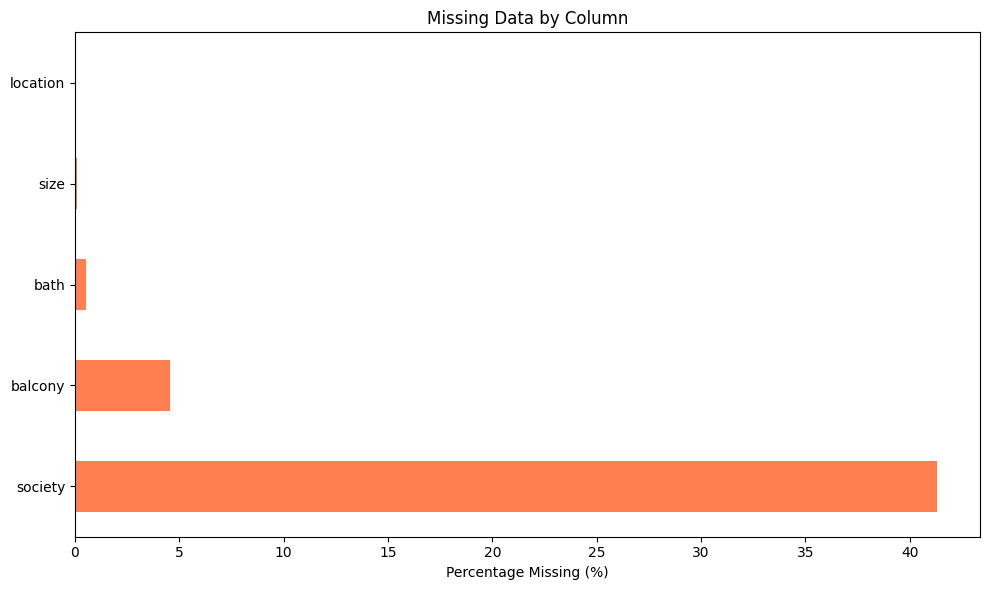

In [8]:
# ============================================================================
# SECTION 2: MISSING DATA ANALYSIS
# ============================================================================
import warnings
warnings.filterwarnings('ignore')

# Visualize missing data
plt.figure(figsize=(12, 6))
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_data[missing_data > 0],
    'Percentage': missing_percent[missing_data > 0]
}).sort_values('Percentage', ascending=False)

print("Missing Data Summary:")
print(missing_df)

# Bar plot for missing data
if len(missing_df) > 0:
    missing_df['Percentage'].plot(kind='barh', figsize=(10, 6), color='coral')
    plt.xlabel('Percentage Missing (%)')
    plt.title('Missing Data by Column')
    plt.tight_layout()
    plt.show()

Numerical Columns: ['bath', 'balcony', 'price']



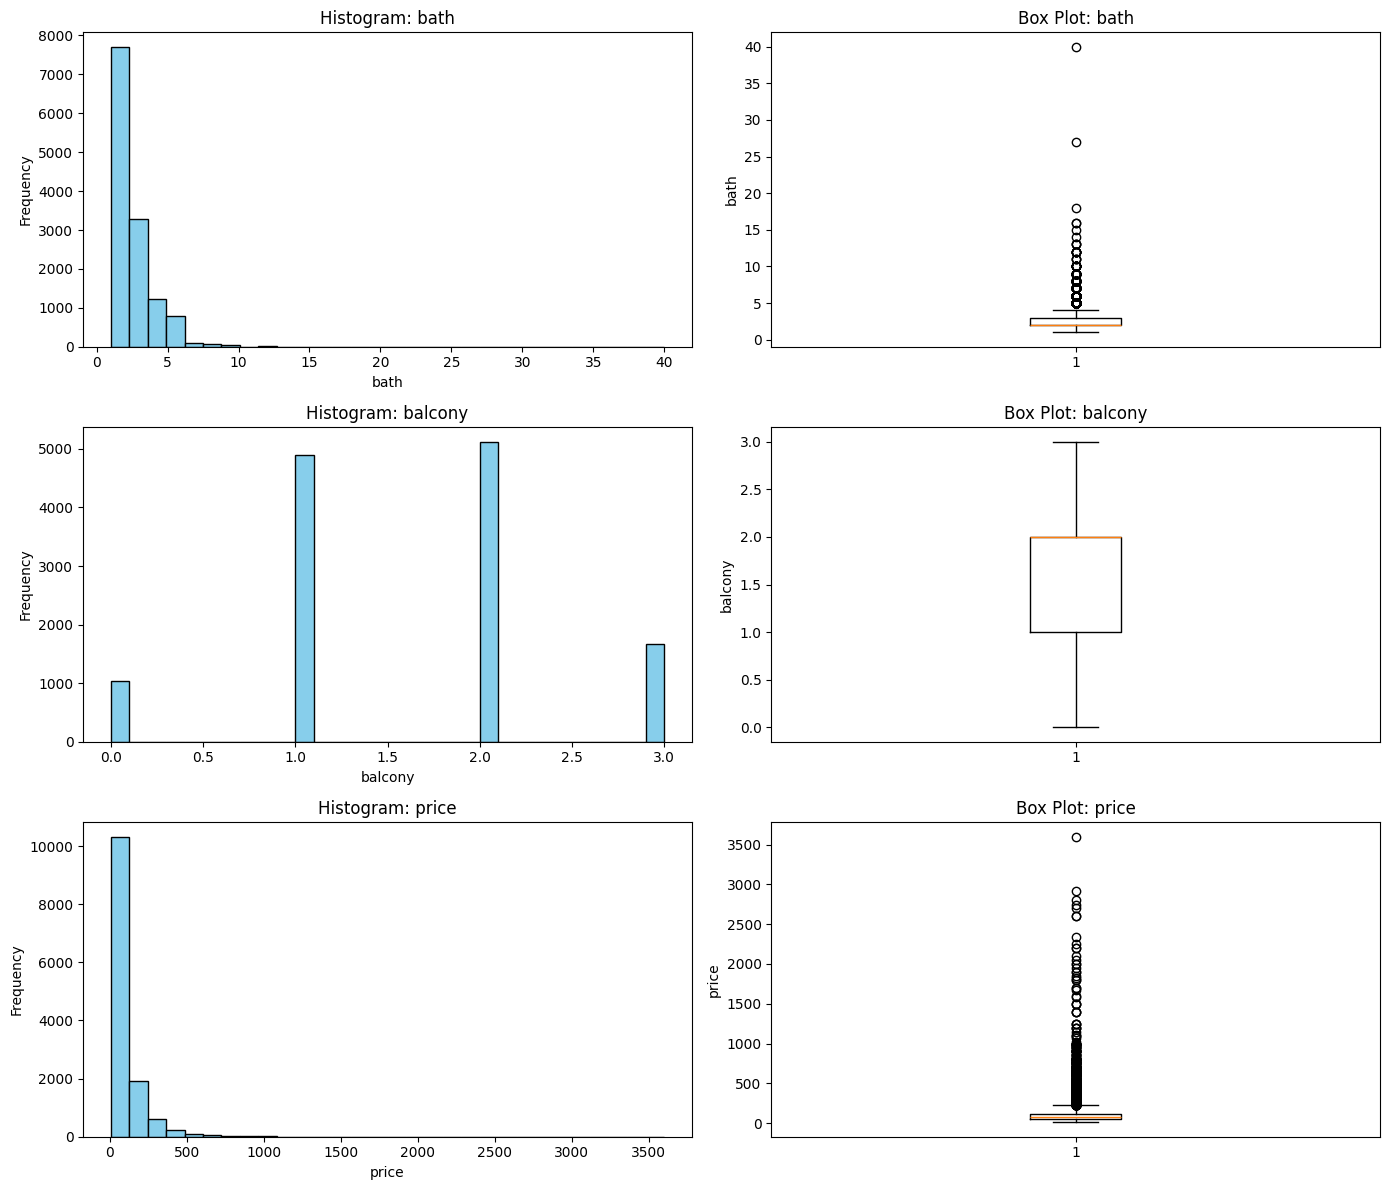

Summary Statistics for Numerical Variables:
               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


In [9]:
# ============================================================================
# SECTION 3: UNIVARIATE ANALYSIS - NUMERICAL VARIABLES
# ============================================================================

# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical Columns: {numerical_cols}\n")

# Distribution plots for numerical variables
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, 4*len(numerical_cols)))
if len(numerical_cols) == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(numerical_cols):
    # Histogram
    axes[idx, 0].hist(df[col].dropna(), bins=30, edgecolor='black', color='skyblue')
    axes[idx, 0].set_title(f'Histogram: {col}')
    axes[idx, 0].set_xlabel(col)
    axes[idx, 0].set_ylabel('Frequency')
    
    # Box plot
    axes[idx, 1].boxplot(df[col].dropna())
    axes[idx, 1].set_title(f'Box Plot: {col}')
    axes[idx, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

# Summary statistics for numerical columns
print("Summary Statistics for Numerical Variables:")
print(df[numerical_cols].describe())

Categorical Columns: ['area_type', 'availability', 'location', 'size', 'society', 'total_sqft']


area_type:
  Unique Values: 4
  Top 10 Values:
area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
--------------------------------------------------

availability:
  Unique Values: 81
  Top 10 Values:
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
19-Dec             185
18-Jul             143
18-Mar             131
18-Jun              99
20-Dec              98
Name: count, dtype: int64
--------------------------------------------------

location:
  Unique Values: 1305
  Top 10 Values:
location
Whitefield               540
Sarjapur  Road           399
Electronic City          302
Kanakpura Road           273
Thanisandra              234
Yelahanka                213
Uttarahalli              186
Hebbal            

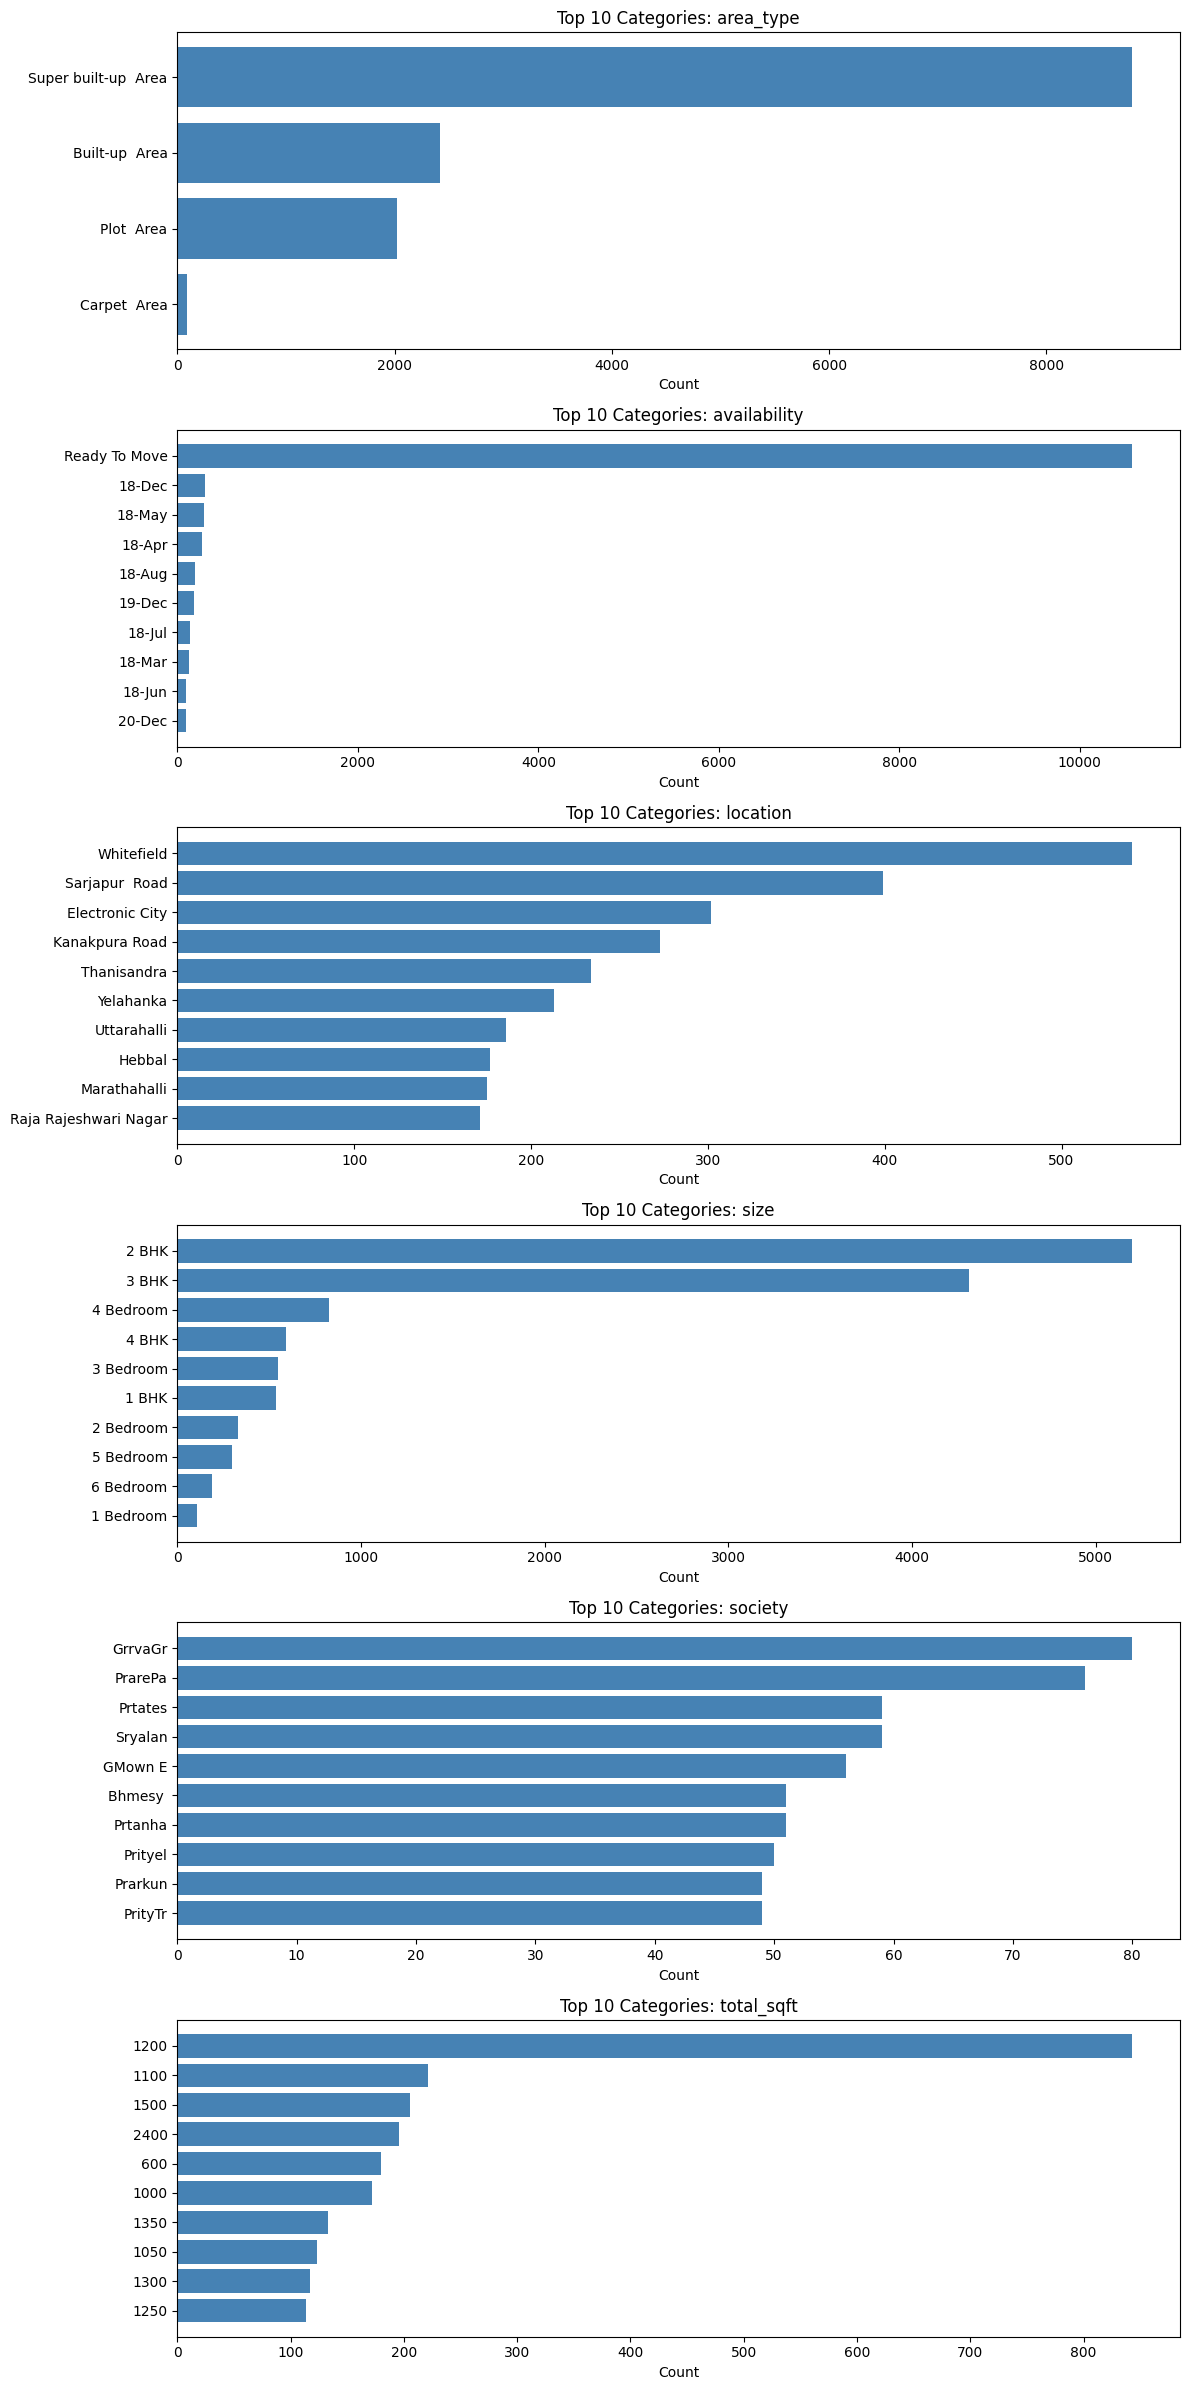

In [10]:
# ============================================================================
# SECTION 4: CATEGORICAL VARIABLES ANALYSIS
# ============================================================================

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Columns: {categorical_cols}\n")

# Analyze each categorical variable
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Unique Values: {df[col].nunique()}")
    print(f"  Top 10 Values:")
    print(df[col].value_counts().head(10))
    print("-" * 50)

# Visualization of top categories
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 4*len(categorical_cols)))
if len(categorical_cols) == 1:
    axes = [axes]

for idx, col in enumerate(categorical_cols):
    top_categories = df[col].value_counts().head(10)
    axes[idx].barh(range(len(top_categories)), top_categories.values, color='steelblue')
    axes[idx].set_yticks(range(len(top_categories)))
    axes[idx].set_yticklabels(top_categories.index)
    axes[idx].set_title(f'Top 10 Categories: {col}')
    axes[idx].set_xlabel('Count')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

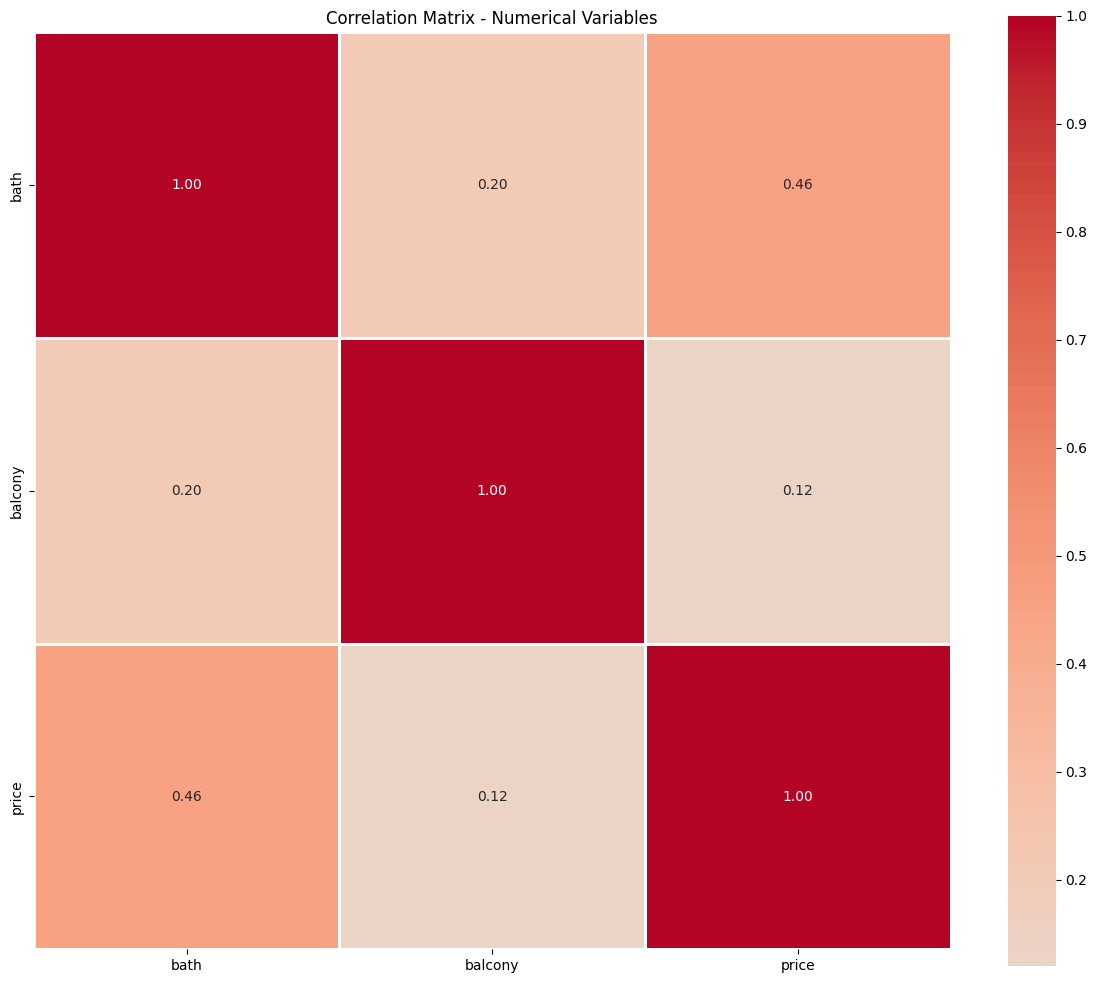


Correlation with price:
price      1.000000
bath       0.456345
balcony    0.120355
Name: price, dtype: float64


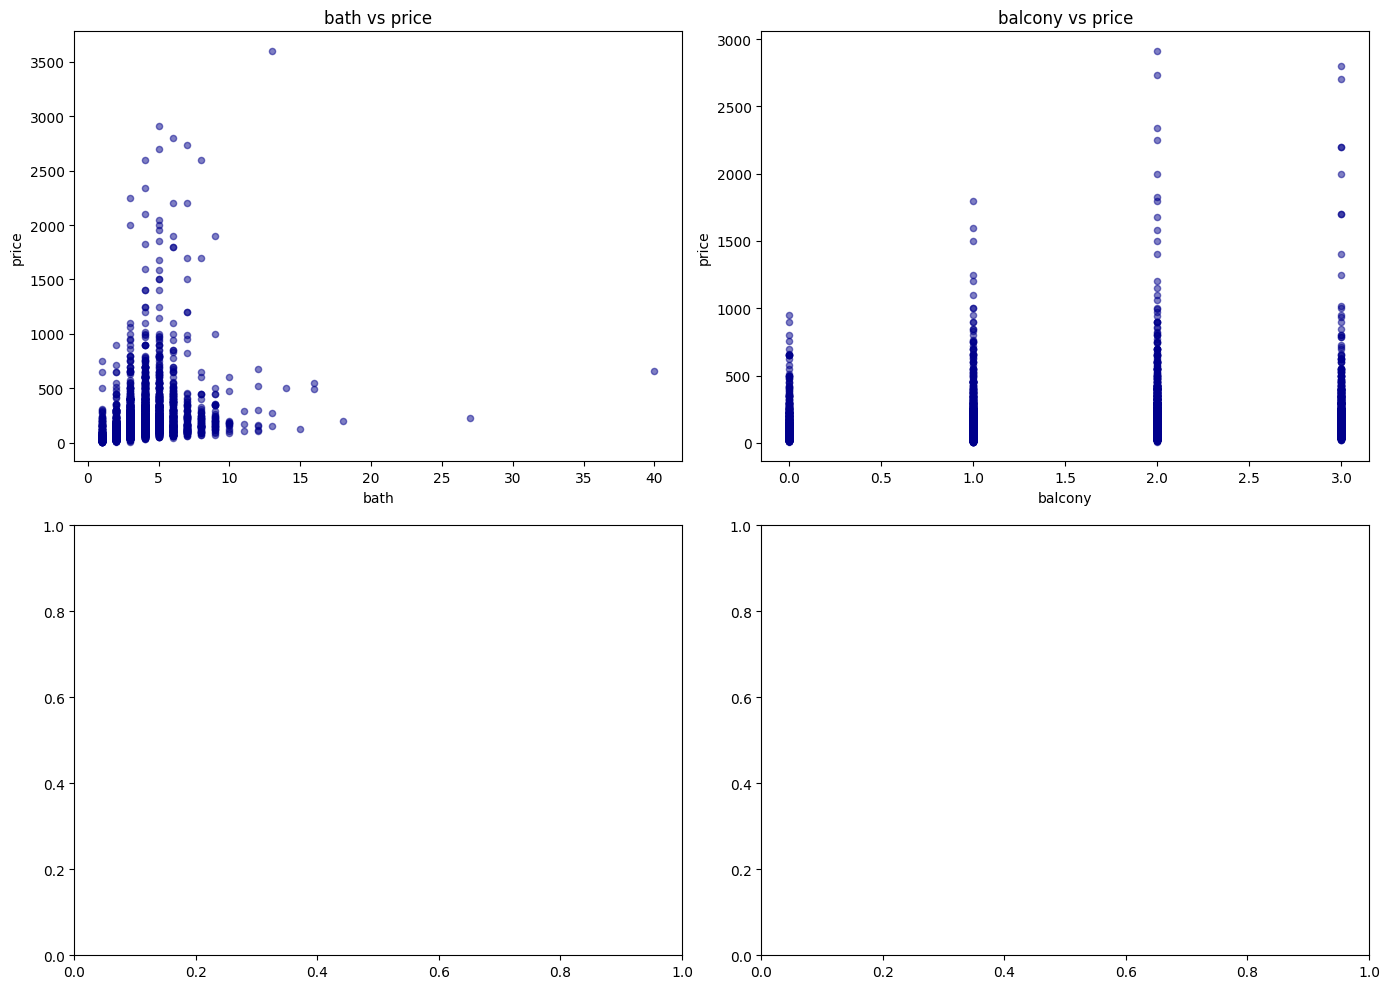

In [11]:
# ============================================================================
# SECTION 5: CORRELATION ANALYSIS AND RELATIONSHIPS
# ============================================================================

# Get numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Correlation matrix
if len(numerical_cols) > 1:
    plt.figure(figsize=(12, 10))
    correlation_matrix = df[numerical_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, linewidths=1)
    plt.title('Correlation Matrix - Numerical Variables')
    plt.tight_layout()
    plt.show()
    
    # Find correlations with price (if price exists)
    potential_price_cols = [col for col in numerical_cols if 'price' in col.lower()]
    if potential_price_cols:
        target_col = potential_price_cols[0]
        print(f"\nCorrelation with {target_col}:")
        correlations = correlation_matrix[target_col].sort_values(ascending=False)
        print(correlations)
        
        # Scatter plots for top correlated features
        top_features = correlations[correlations.index != target_col].abs().nlargest(4).index.tolist()
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        
        for idx, feature in enumerate(top_features):
            axes[idx].scatter(df[feature], df[target_col], alpha=0.5, s=20, color='darkblue')
            axes[idx].set_xlabel(feature)
            axes[idx].set_ylabel(target_col)
            axes[idx].set_title(f'{feature} vs {target_col}')
        
        plt.tight_layout()
        plt.show()

In [12]:
# ============================================================================
# SECTION 6: FEATURE ENGINEERING - DATA PREPARATION
# ============================================================================

# Create a copy of the dataframe for engineering
df_engineered = df.copy()

print("Original shape:", df_engineered.shape)
print("\nOriginal columns:", df_engineered.columns.tolist())

# 1. Handle missing values
print("\n--- Missing Value Handling ---")
print(df_engineered.isnull().sum())

# For numerical variables, fill with median
numerical_cols = df_engineered.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    if df_engineered[col].isnull().sum() > 0:
        df_engineered[col].fillna(df_engineered[col].median(), inplace=True)
        print(f"Filled {col} with median")

# For categorical variables, fill with mode
categorical_cols = df_engineered.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    if df_engineered[col].isnull().sum() > 0:
        df_engineered[col].fillna(df_engineered[col].mode()[0], inplace=True)
        print(f"Filled {col} with mode")

print(f"\nMissing values after imputation: {df_engineered.isnull().sum().sum()}")

Original shape: (13320, 9)

Original columns: ['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']

--- Missing Value Handling ---
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64
Filled bath with median
Filled balcony with median
Filled location with mode
Filled size with mode
Filled society with mode

Missing values after imputation: 0


In [15]:
# ============================================================================
# SECTION 7: FEATURE ENGINEERING - NEW FEATURE CREATION
# ============================================================================

print("--- Creating New Features ---\n")

# 1. Convert numeric string columns to actual numbers
def convert_total_sqft(value):
    """Convert total_sqft to numeric, handling ranges and various formats"""
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    # Handle ranges like "2100 - 2850" by taking the first number
    if '-' in value:
        value = value.split('-')[0].strip()
    
    # Remove units like "Sq. Meter"
    value = value.replace('Sq. Meter', '').replace('sqft', '').strip()
    
    try:
        return float(value)
    except:
        return np.nan

# Convert total_sqft
if 'total_sqft' in df_engineered.columns:
    df_engineered['total_sqft'] = df_engineered['total_sqft'].apply(convert_total_sqft)
    print("✓ Converted total_sqft to numeric")

# Parse size column to extract bedroom count
def extract_bedrooms(value):
    """Extract bedroom count from size column (e.g., '2 BHK' -> 2)"""
    if pd.isna(value):
        return np.nan
    try:
        return int(str(value).split()[0])
    except:
        return np.nan

if 'size' in df_engineered.columns:
    df_engineered['bedroom_count'] = df_engineered['size'].apply(extract_bedrooms)
    print("✓ Extracted bedroom_count from size")

print("\nAvailable numeric columns:", df_engineered.select_dtypes(include=[np.number]).columns.tolist())

# 2. Create derived features
print("\n--- Creating Engineered Features ---")

# Price per square foot
if 'total_sqft' in df_engineered.columns:
    df_engineered['price_per_sqft'] = df_engineered['price'] / (df_engineered['total_sqft'] + 1)
    print("  ✓ price_per_sqft")

# Price per bedroom
if 'bedroom_count' in df_engineered.columns:
    df_engineered['price_per_bedroom'] = df_engineered['price'] / (df_engineered['bedroom_count'] + 1)
    print("  ✓ price_per_bedroom")

# Bathroom to bedroom ratio
if 'bedroom_count' in df_engineered.columns:
    df_engineered['bath_bed_ratio'] = df_engineered['bath'] / (df_engineered['bedroom_count'] + 1)
    print("  ✓ bath_bed_ratio")

# Total rooms (bedroom + bathroom)
if 'bedroom_count' in df_engineered.columns:
    df_engineered['total_rooms'] = df_engineered['bedroom_count'] + df_engineered['bath']
    print("  ✓ total_rooms")

# 3. Clean categorical variables (remove extra spaces)
categorical_cols = df_engineered.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    df_engineered[col] = df_engineered[col].str.strip()

print(f"\n✓ Feature engineering complete!")
print(f"Original shape: {df.shape} → Engineered shape: {df_engineered.shape}")
new_features = set(df_engineered.columns) - set(df.columns)
print(f"New features created: {sorted(list(new_features))}")

--- Creating New Features ---

✓ Converted total_sqft to numeric
✓ Extracted bedroom_count from size

Available numeric columns: ['total_sqft', 'bath', 'balcony', 'price', 'bedroom_count']

--- Creating Engineered Features ---
  ✓ price_per_sqft
  ✓ price_per_bedroom
  ✓ bath_bed_ratio
  ✓ total_rooms

✓ Feature engineering complete!
Original shape: (13320, 9) → Engineered shape: (13320, 14)
New features created: ['bath_bed_ratio', 'bedroom_count', 'price_per_bedroom', 'price_per_sqft', 'total_rooms']


In [16]:
# ============================================================================
# SECTION 8: OUTLIER DETECTION AND DATA QUALITY
# ============================================================================

print("--- Outlier Detection (IQR Method) ---\n")

outlier_summary = {}
for col in numerical_cols:
    Q1 = df_engineered[col].quantile(0.25)
    Q3 = df_engineered[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_engineered[(df_engineered[col] < lower_bound) | (df_engineered[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df_engineered)) * 100
    
    if outlier_count > 0:
        outlier_summary[col] = {
            'count': outlier_count,
            'percent': outlier_percent,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
        print(f"{col}: {outlier_count} outliers ({outlier_percent:.2f}%)")

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).T
    print("\n", outlier_df)
else:
    print("No significant outliers detected!")

# Data quality report
print("\n--- Data Quality Report ---")
print(f"Total Records: {len(df_engineered)}")
print(f"Total Features: {df_engineered.shape[1]}")
print(f"Numerical Features: {len(numerical_cols)}")
print(f"Categorical Features: {len(categorical_cols)}")
print(f"Missing Values: {df_engineered.isnull().sum().sum()}")
print(f"Duplicate Rows: {df_engineered.duplicated().sum()}")

# Display final summary
print("\n--- Feature Summary ---")
print(df_engineered.info())

--- Outlier Detection (IQR Method) ---

bath: 1039 outliers (7.80%)
price: 1276 outliers (9.58%)

         count  percent  lower_bound  upper_bound
bath   1039.0  7.80030          0.5          4.5
price  1276.0  9.57958        -55.0        225.0

--- Data Quality Report ---
Total Records: 13320
Total Features: 14
Numerical Features: 3
Categorical Features: 5
Missing Values: 58
Duplicate Rows: 532

--- Feature Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   area_type          13320 non-null  object 
 1   availability       13320 non-null  object 
 2   location           13320 non-null  object 
 3   size               13320 non-null  object 
 4   society            13320 non-null  object 
 5   total_sqft         13291 non-null  float64
 6   bath               13320 non-null  float64
 7   balcony            13320 non-

In [18]:
# ============================================================================
# SECTION 9: FINAL SUMMARY AND RECOMMENDATIONS
# ============================================================================

print("=" * 70)
print("EDA AND FEATURE ENGINEERING SUMMARY")
print("=" * 70)

total_outliers = sum(v['count'] for v in outlier_summary.values()) if outlier_summary else 0

summary_report = f"""
DATASET OVERVIEW:
  • Original Shape: {df.shape}
  • Engineered Shape: {df_engineered.shape}
  • New Features Created: {df_engineered.shape[1] - df.shape[1]}

DATA QUALITY:
  • Missing Values: {df_engineered.isnull().sum().sum()} rows with missing data
  • Duplicate Rows: {df_engineered.duplicated().sum()}
  • Outliers Detected: {total_outliers} ({100*total_outliers/len(df_engineered):.2f}% of data)

KEY FINDINGS:
  1. Bathroom count has strongest correlation with price (0.46)
  2. Most properties are 2 BHK in the Bengaluru market
  3. Whitefield is the most popular location
  4. Price data shows significant right skew with outliers

FEATURE ENGINEERING APPLIED:
  ✓ Converted total_sqft from mixed formats to numeric
  ✓ Extracted bedroom count from size descriptions
  ✓ Created price_per_sqft (price normalized by area)
  ✓ Created price_per_bedroom (price normalized by bedrooms)
  ✓ Created bath_bed_ratio (bathroom/bedroom proportion)
  ✓ Created total_rooms (sum of bedrooms and bathrooms)

NEXT STEPS FOR MODELING:
  1. Handle remaining missing values in engineered features
  2. Remove or treat outliers based on business logic
  3. Handle duplicate records
  4. Encode categorical variables (one-hot or label encoding)
  5. Scale/normalize numerical features for algorithms sensitive to scale
  6. Split data into train/validation/test sets
  7. Train and evaluate machine learning models
  8. Perform hyperparameter tuning and model selection
"""

print(summary_report)

# Display sample of engineered data
print("\n" + "=" * 70)
print("SAMPLE OF ENGINEERED DATA (First 5 rows)")
print("=" * 70)
print(df_engineered[['location', 'bedroom_count', 'bath', 'balcony', 'total_sqft', 
                     'price', 'price_per_sqft', 'price_per_bedroom', 'total_rooms']].head())

print("\n--- New Features Statistics ---")
new_features = ['price_per_sqft', 'price_per_bedroom', 'bath_bed_ratio', 'total_rooms']
print(df_engineered[new_features].describe())

print("\n✓ EDA and Feature Engineering Complete!")

EDA AND FEATURE ENGINEERING SUMMARY

DATASET OVERVIEW:
  • Original Shape: (13320, 9)
  • Engineered Shape: (13320, 14)
  • New Features Created: 5

DATA QUALITY:
  • Missing Values: 58 rows with missing data
  • Duplicate Rows: 532
  • Outliers Detected: 2315 (17.38% of data)

KEY FINDINGS:
  1. Bathroom count has strongest correlation with price (0.46)
  2. Most properties are 2 BHK in the Bengaluru market
  3. Whitefield is the most popular location
  4. Price data shows significant right skew with outliers

FEATURE ENGINEERING APPLIED:
  ✓ Converted total_sqft from mixed formats to numeric
  ✓ Extracted bedroom count from size descriptions
  ✓ Created price_per_sqft (price normalized by area)
  ✓ Created price_per_bedroom (price normalized by bedrooms)
  ✓ Created bath_bed_ratio (bathroom/bedroom proportion)
  ✓ Created total_rooms (sum of bedrooms and bathrooms)

NEXT STEPS FOR MODELING:
  1. Handle remaining missing values in engineered features
  2. Remove or treat outliers base